# Validation of Python GPA implementation against CyMorph

This notebook validates the new Python implementation of the Gradient Pattern Analysis (GPA)
method by comparing its results with the original CyMorph implementation.

The reference implementation used for comparison is:

https://github.com/rsautter/CyMorph

Two FITS images are evaluated. The expected G2 values obtained with the original CyMorph
pipeline are:

| Image | Original CyMorph G2 |
|---|---:|
| 587722952230240617.fit | 1.2774484157562256 |
| 587722952230175145.fit | 1.2083033323287964 |

The goal is to verify whether the Python implementation reproduces the GPA measurements.


---

## Author

**Carlos Eduardo Falandes**

M.Sc. Candidate in Applied Computing  
National Institute for Space Research (INPE), Brazil

**Master's Dissertation:**  
*Gradient Pattern Analysis (GPA): Two New Applications for Pattern Characterization in Physics of Extreme Events and Extragalactic Astronomy*

**Contact:** carloseduardofalandes@gmail.com

This notebook is part of the GPA Python implementation developed during the author's master's research. It is intended as a basic introduction to the library and demonstrates the fundamental workflow for applying the Gradient Pattern Analysis method to two-dimensional scalar fields.

In [1]:
import sys
sys.path.append("../src")

from gpa.gpa import GPA
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits

## Dataset

The validation uses two FITS images previously analyzed with CyMorph.

For each galaxy, two FITS files are used:

- `newMat`: processed image used as input for the GPA calculation.
- `segmentationMask`: segmentation mask generated during the CyMorph preprocessing pipeline.

The datasets are stored in:


In [2]:
data_587722952230240617 = fits.getdata(
    "../../data/validation_gpa/newMat_587722952230240617.fit"
)

segmentationMask_587722952230240617 = fits.getdata(
    "../../data/validation_gpa/mask_587722952230240617.fit"
)


data_587722952230175145 = fits.getdata(
    "../../data/validation_gpa/newMat_587722952230175145.fit"
)

segmentationMask_587722952230175145 = fits.getdata(
    "../../data/validation_gpa/mask_587722952230175145.fit"
)

In [3]:
segmentationMask_587722952230240617 = 1 - segmentationMask_587722952230240617

segmentationMask_587722952230175145 = 1 - segmentationMask_587722952230175145

## Data Visualization

Before applying the GPA method, we visualize the processed FITS images (`newMat`) and their corresponding segmentation masks.

The `newMat` images correspond to the preprocessed galaxy images generated by the CyMorph pipeline and are used as input for the GPA calculation.

The segmentation masks identify the regions considered during the analysis, allowing the comparison between the original CyMorph processing and the new Python implementation.

The visualization below shows:

- **Left panel:** processed galaxy image (`newMat`) with logarithmic intensity scaling.
- **Right panel:** corresponding segmentation mask used during the GPA analysis.

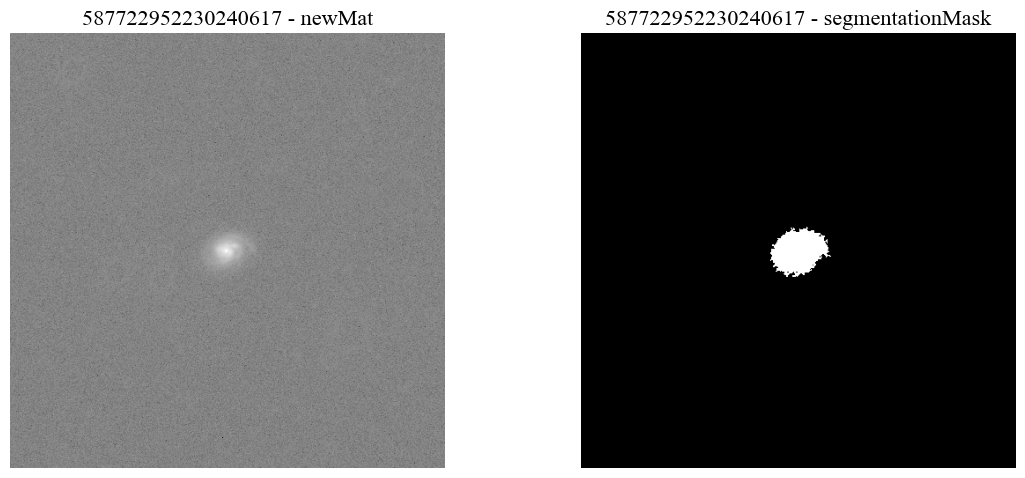

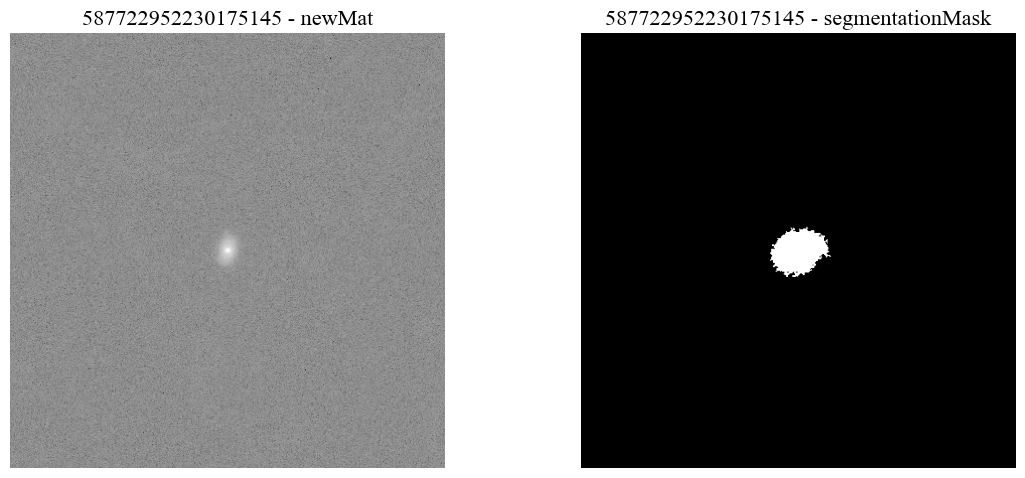

In [4]:
def plot_image_and_mask(image, mask, title):

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Image display with logarithmic stretch
    ax[0].imshow(
        np.log10(image - image.min() + 1),
        cmap="gray"
    )
    ax[0].set_title(f"{title} - newMat")
    ax[0].axis("off")


    # Segmentation mask
    ax[1].imshow(
        mask,
        cmap="gray"
    )
    ax[1].set_title(f"{title} - segmentationMask")
    ax[1].axis("off")


    plt.tight_layout()
    plt.show()


plot_image_and_mask(
    data_587722952230240617,
    segmentationMask_587722952230240617,
    "587722952230240617"
)


plot_image_and_mask(
    data_587722952230175145,
    segmentationMask_587722952230175145,
    "587722952230175145"
)

## GPA Evaluation and Validation

The GPA method is applied to the two galaxies using the same parameters adopted in the original CyMorph analysis.

The evaluation uses:

- the preprocessed galaxy image (`newMat`);
- the corresponding segmentation mask;
- the galaxy center position obtained from the CyMorph pipeline;
- the same GPA tolerance parameters (`mtol`, `ftol`, and `ptol`).

The computed second-order gradient moment (`G2`) is then compared with the reference values obtained using the original CyMorph implementation.

The expected CyMorph results are:

| Galaxy | CyMorph G2 |
|---|---:|
| 587722952230240617 | 1.2774484157562256 |
| 587722952230175145 | 1.2083033323287964 |

The difference between implementations is calculated as:

\[
\Delta G_2 = G_2^{Python} - G_2^{CyMorph}
\]

and the relative error as:

\[
\epsilon = \frac{|G_2^{Python}-G_2^{CyMorph}|}{G_2^{CyMorph}}
\]

In [5]:
# Reference CyMorph results

cymorph_results = {
    "587722952230240617": 1.2774484157562256,
    "587722952230175145": 1.2083033323287964
}


# GPA parameters used in CyMorph validation

gpa_parameters = {
    "mtol": 0.019999999552965164,
    "ftol": 0.029999999329447746,
    "ptol": 0.009999999776482582
}


# Galaxy center position

center_x = 247.2010955810547
center_y = 247.68589782714844



def run_gpa_validation(image, mask, galaxy_id):

    gpaObject = GPA(image)

    gpaObject.setPosition(
        center_x,
        center_y
    )

    result = gpaObject.evaluate(
        mask=mask,
        **gpa_parameters
    )

    return result



results = {}


results["587722952230240617"] = run_gpa_validation(
    data_587722952230240617,
    segmentationMask_587722952230240617,
    "587722952230240617"
)


results["587722952230175145"] = run_gpa_validation(
    data_587722952230175145,
    segmentationMask_587722952230175145,
    "587722952230175145"
)

In [6]:
results

{'587722952230240617': {'G1': None,
  'G2': np.float32(1.7844738),
  'G3': None,
  'G4': None},
 '587722952230175145': {'G1': None,
  'G2': np.float32(1.7796208),
  'G3': None,
  'G4': None}}

In [7]:
validation = []


for galaxy_id, result in results.items():

    python_g2 = result["G2"]

    cymorph_g2 = cymorph_results[galaxy_id]

    difference = python_g2 - cymorph_g2

    relative_error = abs(difference / cymorph_g2)


    validation.append(
        {
            "Galaxy": galaxy_id,
            "CyMorph G2": cymorph_g2,
            "Python GPA G2": python_g2,
            "Difference": difference,
            "Relative Error": relative_error
        }
    )


validation = pd.DataFrame(validation)

validation

,Galaxy,CyMorph G2,Python GPA G2,Difference,Relative Error
0,587722952230240617,1.277448,1.784474,0.507025,0.396905
1,587722952230175145,1.208303,1.779621,0.571317,0.472826


# Difference Between the Original CyMorph GPA and the Python GPA Implementation

The G2 values obtained with the Python implementation differ from those produced by the original CyMorph implementation.

| Galaxy | CyMorph G2 | Python GPA G2 | Difference | Relative Error |
|--------:|-----------:|--------------:|-----------:|---------------:|
| 587722952230240617 | 1.277448 | 1.784474 | 0.507025 | 0.396905 |
| 587722952230175145 | 1.208303 | 1.779621 | 0.571317 | 0.472826 |

## Reason for the Difference

The discrepancy originates from the way radially symmetric gradient vectors are identified and removed.

### Original CyMorph implementation

In the original CyMorph implementation, gradient vectors are grouped according to their radial distance from the analysis center. For each radius, every vector is compared with every other vector belonging to the same radius. If two vectors have similar magnitudes and approximately opposite orientations, they are considered a symmetric pair and removed.

However, the algorithm does **not** verify whether the two vectors are actually positioned on opposite sides of the analysis center. As a consequence, vectors located at the same radius but in unrelated positions may still be classified as a symmetric pair.

### Python implementation

The Python implementation introduces an additional geometric constraint. Besides requiring similar magnitudes and approximately opposite orientations, it also verifies that the two pixels are spatially opposite with respect to the analysis center.

Specifically, the following condition is enforced:

```python
position_opposite = (
    abs((px + px2) - 2*self.cx) <= rtol
    and
    abs((py + py2) - 2*self.cy) <= rtol
)
```

This condition ensures that

\[
(px, py) + (px_2, py_2) \approx 2(cx, cy),
\]

meaning that the midpoint between the two pixels coincides (within a tolerance) with the analysis center.

Therefore, two vectors are removed only if all three conditions are satisfied:

- Similar gradient magnitude;
- Approximately opposite gradient orientation;
- Opposite spatial position with respect to the analysis center.

```python
if abs(self.mods[py, px] - self.mods[py2, px2]) <= mtol * self.maxGrad:

    angle_opposite = (
        abs(
            self._angleDifference(
                self.phases[py, px],
                self.phases[py2, px2]
            ) - np.pi
        ) <= ftol
    )

    position_opposite = (
        abs((px + px2) - 2*self.cx) <= rtol
        and
        abs((py + py2) - 2*self.cy) <= rtol
    )

    if angle_opposite and position_opposite:

        self.gradient_asymmetric_dx[py, px] = np.float32(0.0)
        self.gradient_asymmetric_dy[py, px] = np.float32(0.0)

        self.gradient_asymmetric_dx[py2, px2] = np.float32(0.0)
        self.gradient_asymmetric_dy[py2, px2] = np.float32(0.0)

        break
```

## Consequences

The additional positional constraint makes the symmetry detection more geometrically consistent. Unlike the original implementation, vectors are considered symmetric only when they are both directionally opposite and spatially opposite relative to the analysis center.

As a consequence, fewer vectors are incorrectly removed as symmetric, leaving a larger set of asymmetric vectors and resulting in higher G2 values than those produced by the original CyMorph implementation.